In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\ryang\Data Analysis\retail_store_sales.csv")

In [3]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [7]:
df.shape

(12575, 11)

In [9]:
df.dtypes

Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object

In [11]:
df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [13]:
df.duplicated().any()

False

In [15]:
df["Customer ID"].nunique()

25

In [17]:
df["Category"].nunique()

8

In [19]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

In [21]:
df.dtypes

Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied            object
dtype: object

In [23]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [25]:
df.dropna(inplace=True)

In [27]:
df.shape

(7579, 11)

In [29]:
df["Customer ID"].nunique()

25

In [31]:
df = df.reset_index(drop=True)

In [54]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
4,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True


In [76]:
df.to_csv(r"C:\Users\ryang\Data Analysis\retail_sales.csv", index=False)

In [56]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
4,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True


Text(0, 0.5, 'Frequency')

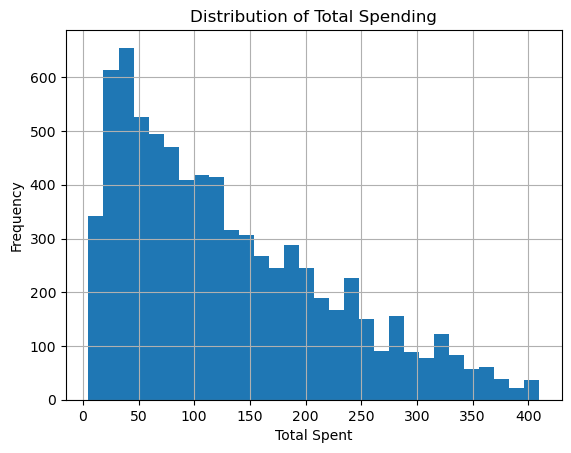

In [66]:
## Revenue Distribution
df["Total Spent"].hist(bins=30)

plt.title("Distribution of Total Spending")

plt.xlabel("Total Spent")

plt.ylabel("Frequency")

# Most purchases fall below $100, with a small number of high-value transactions.

<Axes: xlabel='Payment Method'>

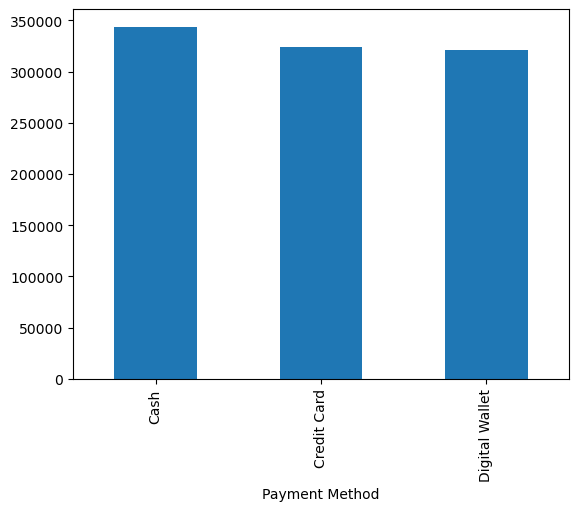

In [77]:
## Revenue by payment method
payment_sales = df.groupby("Payment Method")["Total Spent"].sum()

payment_sales.plot(kind="bar")

# Cash has the highest revenue amongst the payment methods.

<Axes: xlabel='Payment Method'>

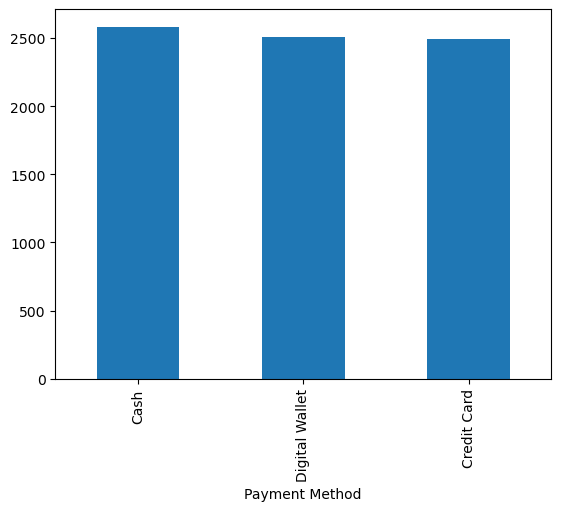

In [89]:
# Payment Method
df["Payment Method"].value_counts().plot(kind="bar")

# Cash is the most frequently used payment method.

<Axes: xlabel='Category'>

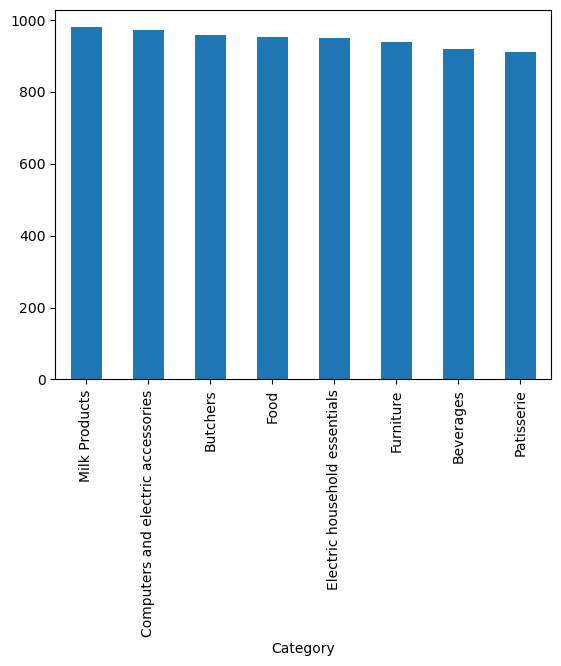

In [91]:
# Payment Category
df["Category"].value_counts().plot(kind="bar")

# Milk Products accounts for the highest number of purchases.

<Axes: xlabel='Category'>

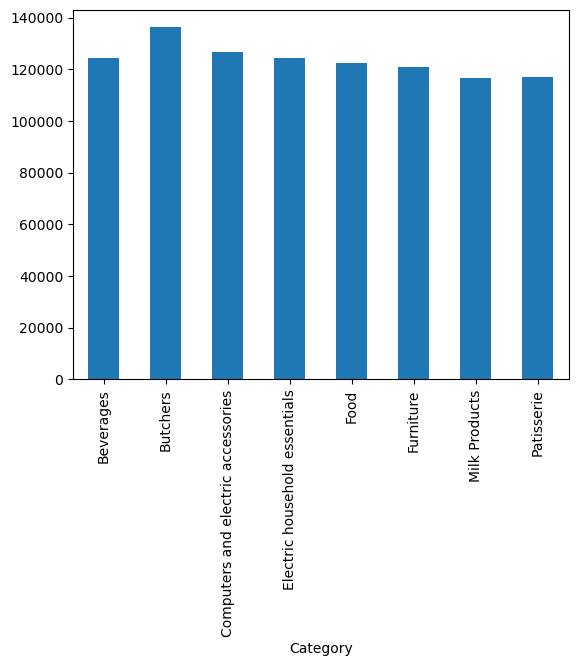

In [93]:
# Revenue by Category
category_sales = df.groupby("Category")["Total Spent"].sum()

category_sales.plot(kind="bar")

# Butchers contribute the highest revenue despite having fewer transactions than Milk products.

<Axes: xlabel='Location'>

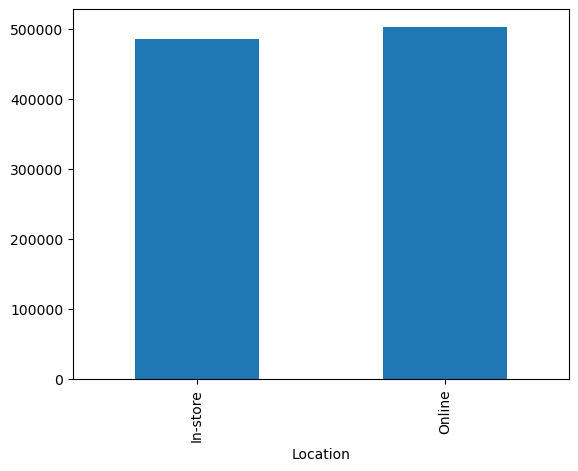

In [100]:
# Revenue by Store Location
location_sales = df.groupby("Location")["Total Spent"].sum()

location_sales.plot(kind="bar")

# Online Sales contribute the highest revenue 

<Axes: xlabel='Transaction Date'>

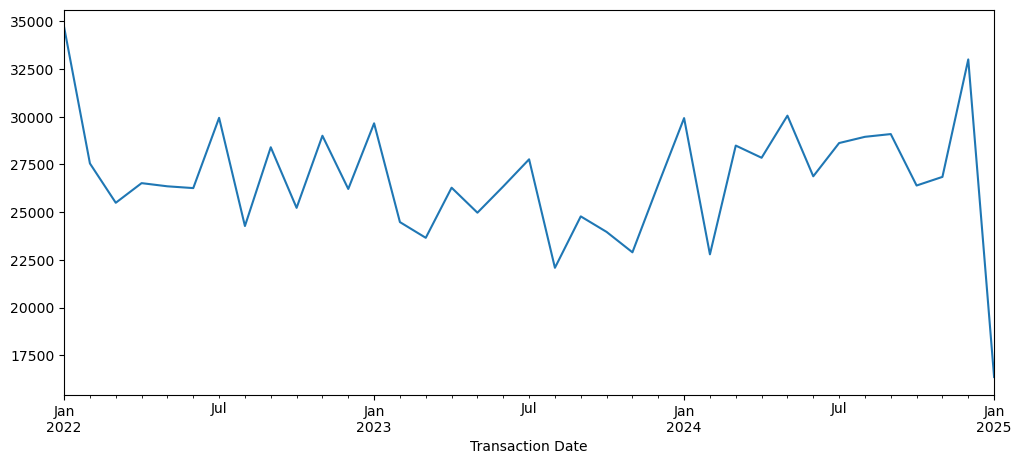

In [108]:
# Monthly sales trend
monthly_sales = (
    df.groupby(df["Transaction Date"].dt.to_period("M"))["Total Spent"]
      .sum()
)

monthly_sales.plot(figsize=(12,5))

# Sales increased steadily throughout early 2024 before declining massively in late 2024.

<Axes: xlabel='Category'>

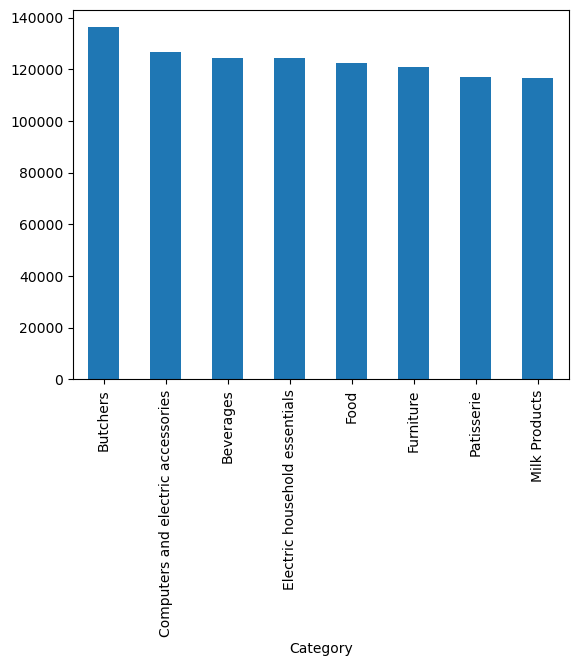

In [137]:
# Top category
top_products = df.groupby("Category")["Total Spent"].sum().sort_values(ascending=False)
top_products.plot(kind="bar")

# Butchers category generates the highest revenue and should remain a focus for inventory planning.

<Axes: xlabel='Customer ID'>

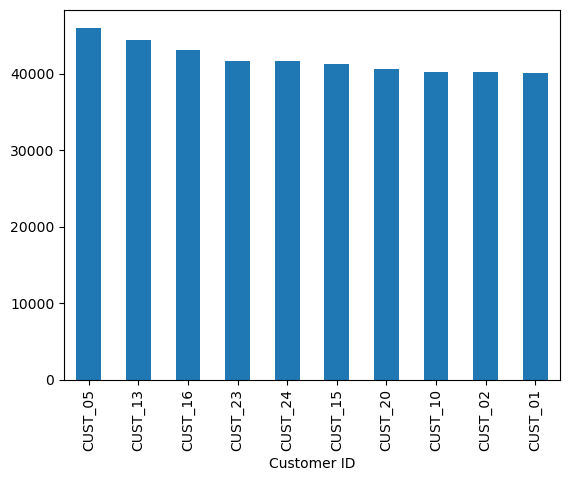

In [150]:
# Top Customers
top_customers = df.groupby("Customer ID")["Total Spent"].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind="bar")

#  Customer with Customer ID "CUST_05" contributes a significant share of revenue.

In [161]:
# Correlation
corr = df.corr(numeric_only=True)

corr

,Price Per Unit,Quantity,Total Spent
Price Per Unit,1.000000,0.007422,0.626568
Quantity,0.007422,1.000000,0.713918
Total Spent,0.626568,0.713918,1.000000


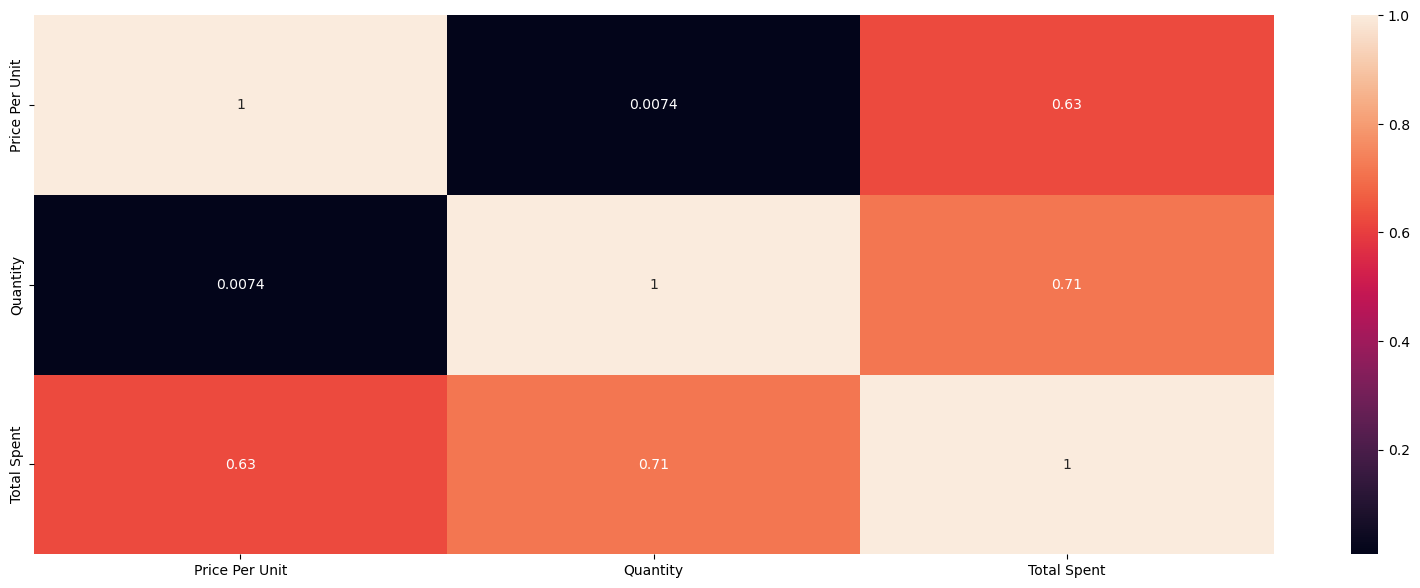

In [163]:
# Correlation heatmap
sns.heatmap(corr, annot = True)

plt.rcParams['figure.figsize'] = (20,7)

plt.show()

| Correlation | Meaning                        |
| ----------: | ------------------------------ |
|         1.0 | Perfect positive relationship  |
|         0.8 | Strong positive relationship   |
|         0.5 | Moderate positive relationship |
|           0 | No linear relationship         |
|        -0.5 | Moderate negative relationship |
|        -0.8 | Strong negative relationship   |
|        -1.0 | Perfect negative relationship  |
